In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

INST = ["COP", "GOV", "INS", "JUD", "MIL", "OPP", "REB", "SEP", "SPY", "UAF", "AGR", "BUS", "CRM", "CVL", "DEV", "EDU", "ELI", "ENV", "HLH", "HRI", "LAB", "LEG", "MED", "REF", "MOD", "RAD"]
NEW_DATA = False

In [3]:
if NEW_DATA:
    start = pd.to_datetime('2016-01-04')
    end = pd.to_datetime('2025-05-19')

    merged_df = pd.DataFrame()
    existing_pairs = None

    while start <= end:
        file_path = (
            f'D:/gdelt_data/weekly_pw_parts_all/'
            f'weekly_country_agg_{start.strftime("%Y%m%d")}.parquet'
        )

        try:
            df = pd.read_parquet(file_path)

            if existing_pairs is None:
                # First successful week: keep all pairs
                merged_df = df.copy()
                existing_pairs = df["pair"].unique()

            else:
                # Keep only pairs that survived up to the previous week
                df = df[df["pair"].isin(existing_pairs)]

                merged_df = pd.concat(
                    [merged_df, df],
                    ignore_index=True
                )
                # keep only pairs that have been in every week up to the current week
                merged_df = merged_df[merged_df["pair"].isin(existing_pairs)]

                # Update survivors for next week
                existing_pairs = df["pair"].unique()

            print(f"Successfully read: {file_path}")
            print(f"Length of existing_pairs: {len(existing_pairs)}")

        except Exception as e:
            print(f"Failed to read: {file_path} with error: {e}")

        start += pd.Timedelta(weeks=1)

In [4]:
if NEW_DATA:
    print("Saving merged DataFrame to CSV...")
    merged_df.to_csv('all_complete_survivors.csv', index=False)
else:
    print("Loading merged DataFrame from CSV...")
    merged_df = pd.read_csv('all_complete_survivors.csv')
print("Length Check")
print(len(merged_df) / 2907)


Loading merged DataFrame from CSV...
Length Check
490.0


In [5]:
coverage_distribution = {"pair": [], "mean_coverage": [], "min_coverage": [], "max_coverage": []}
for pair in merged_df["pair"].unique():
    pair_df = merged_df[merged_df["pair"] == pair]
    mean_coverage = pair_df["mentions"].mean()
    min_coverage = pair_df["mentions"].min()
    max_coverage = pair_df["mentions"].max()
    coverage_distribution["pair"].append(pair)
    coverage_distribution["mean_coverage"].append(mean_coverage)
    coverage_distribution["min_coverage"].append(min_coverage)
    coverage_distribution["max_coverage"].append(max_coverage)
coverage_distribution_df = pd.DataFrame(coverage_distribution).sort_values(by="mean_coverage", ascending=False)

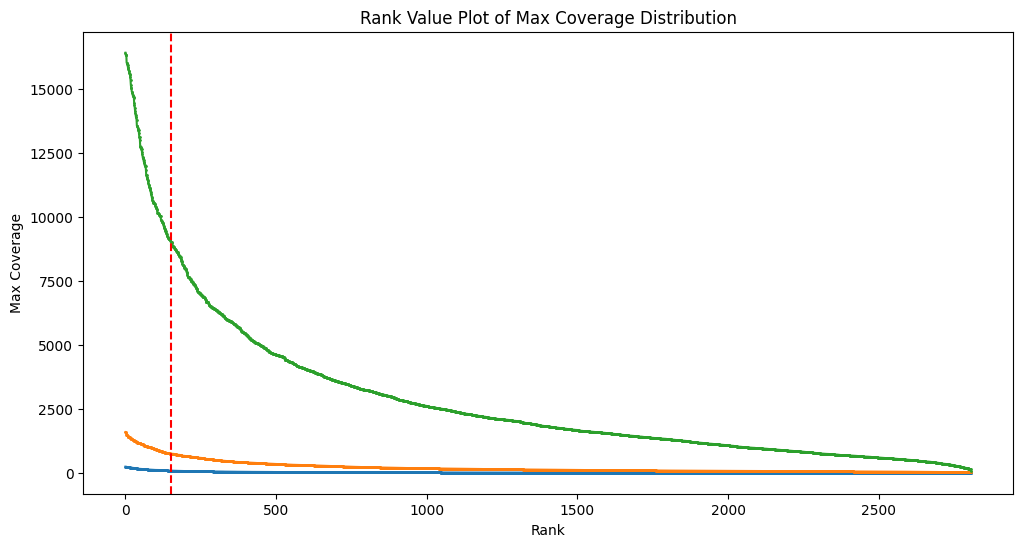

Threshold: 75, Intersecting Pairs: 270
Threshold: 100, Intersecting Pairs: 224
Threshold: 150, Intersecting Pairs: 149
Threshold: 200, Intersecting Pairs: 120
Threshold: 250, Intersecting Pairs: 98
Threshold: 300, Intersecting Pairs: 78
Threshold: 400, Intersecting Pairs: 60
Threshold: 500, Intersecting Pairs: 46
Threshold: 600, Intersecting Pairs: 38
Threshold: 700, Intersecting Pairs: 33


In [6]:
# visualize the respective distributions of min and mean coverage
sorted_min_coverage = sorted(coverage_distribution["min_coverage"], reverse=True)
sorted_mean_coverage = sorted(coverage_distribution["mean_coverage"], reverse=True)
sorted_max_coverage = sorted(coverage_distribution["max_coverage"], reverse=True)

#create rank value plot for both
plt.figure(figsize=(12, 6))
plt.plot(sorted_min_coverage[100:], marker='o', linestyle='-', markersize=1)
plt.title('Rank Value Plot of Min Coverage Distribution')
plt.xlabel('Rank')
plt.ylabel('Min Coverage')
plt.plot(sorted_mean_coverage[100:], marker='o', linestyle='-', markersize=1)
plt.title('Rank Value Plot of Mean Coverage Distribution')
plt.xlabel('Rank')
plt.ylabel('Mean Coverage')
plt.plot(sorted_max_coverage[100:], marker='o', linestyle='-', markersize=1)
plt.title('Rank Value Plot of Max Coverage Distribution')
plt.xlabel('Rank')
plt.ylabel('Max Coverage')
plt.axvline(x=150, color='r', linestyle='--', label='Rank 150')
plt.show()

# for select values of min and mean coverage, find the intersecting pairs
for threshold in [75, 100, 150, 200, 250, 300, 400, 500, 600, 700]:
    min_coverage_pairs = coverage_distribution_df[coverage_distribution_df["min_coverage"] >= threshold]["pair"].tolist()
    mean_coverage_pairs = coverage_distribution_df[coverage_distribution_df["mean_coverage"] >= threshold]["pair"].tolist()
    max_coverage_pairs = coverage_distribution_df[coverage_distribution_df["max_coverage"] >= threshold]["pair"].tolist()
    intersecting_pairs = set(min_coverage_pairs).intersection(set(mean_coverage_pairs)).intersection(set(max_coverage_pairs))
    print(f"Threshold: {threshold}, Intersecting Pairs: {len(intersecting_pairs)}")

In [7]:
mean_coverage_700 = []
for pair in merged_df["pair"].unique():
    pair_df = merged_df[merged_df["pair"] == pair]
    mean_coverage = pair_df["mentions"].mean()
    if mean_coverage >= 700:
        mean_coverage_700.append(pair)

In [8]:
min_coverage_75 = []
for pair in merged_df["pair"].unique():
    pair_df = merged_df[merged_df["pair"] == pair]
    min_coverage = pair_df["mentions"].min()
    if min_coverage >= 75:
        min_coverage_75.append(pair)

In [9]:
max_coverage_7500 = []
for pair in merged_df["pair"].unique():
    pair_df = merged_df[merged_df["pair"] == pair]
    max_coverage = pair_df["mentions"].max()
    if max_coverage >= 7500:
        max_coverage_7500.append(pair)

In [10]:
def get_pair_types(pair_list):
    print(f"Total pairs: {len(pair_list)}")
    cfs = []
    for pair in pair_list:
        act1 = pair.split(" -> ")[0]
        act2 = pair.split(" -> ")[1]
        if len(act1) > 3:
            act1 = act1[-3:]
        if len(act2) > 3:
            act2 = act2[-3:]
        if act1 in INST:
            if act2 in INST:
                cf = 'ii'
            else:
                cf = 'ig'
        else:
            if act2 in INST:
                cf = 'gi'
            else:
                cf = 'gg'
        cfs.append(cf)
    # get relative counts of each cf
    print("Counts of each cf:")
    print(pd.Series(cfs).value_counts(normalize=True))
    # Visualize the counts of each cf
    plt.figure(figsize=(8, 6))
    pd.Series(cfs).value_counts().plot(kind='bar')

Total pairs: 270
Counts of each cf:
ii    0.296296
gi    0.266667
ig    0.244444
gg    0.192593
Name: proportion, dtype: float64


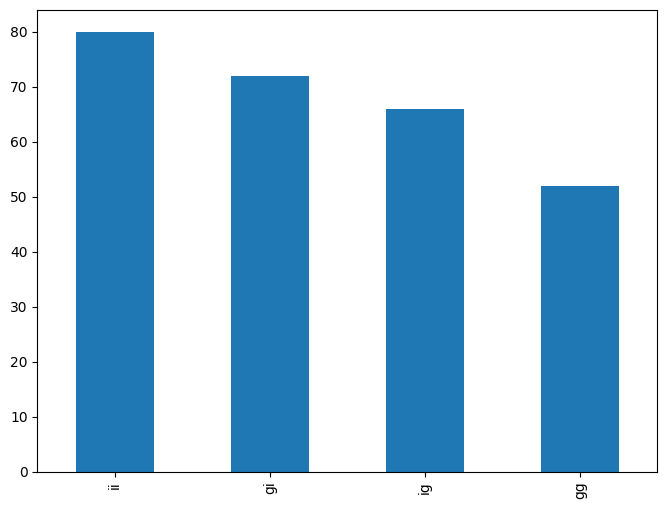

In [11]:
get_pair_types(min_coverage_75)

Total pairs: 277
Counts of each cf:
gg    0.324910
ii    0.227437
gi    0.223827
ig    0.223827
Name: proportion, dtype: float64


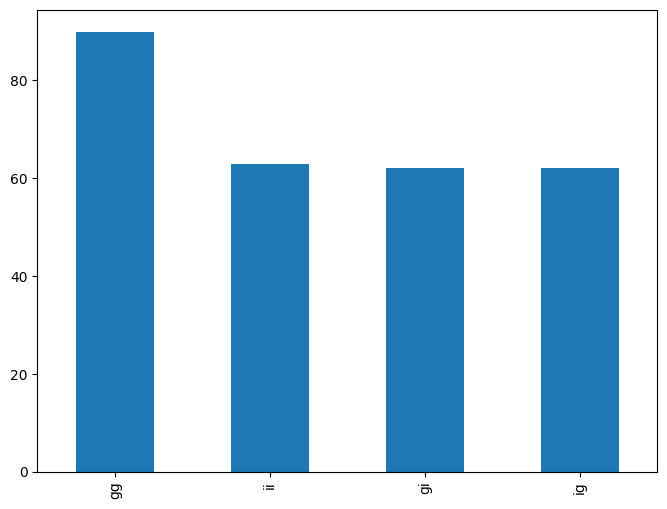

In [12]:
get_pair_types(mean_coverage_700)

Total pairs: 319
Counts of each cf:
gg    0.460815
gi    0.228840
ig    0.222571
ii    0.087774
Name: proportion, dtype: float64


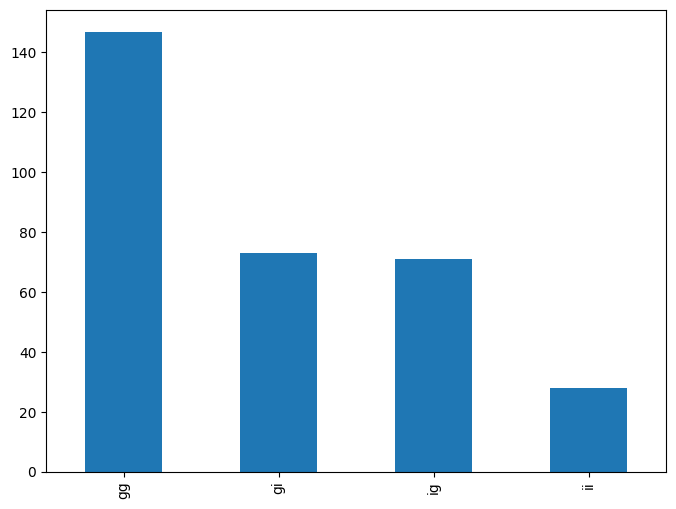

In [13]:
get_pair_types(max_coverage_7500)

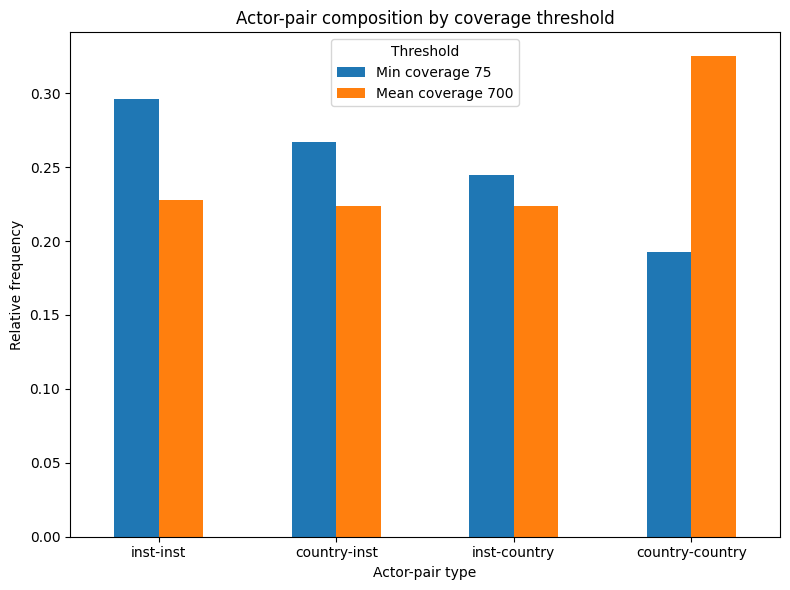

In [16]:
def get_pair_type_counts(pair_list):
    cfs = []

    for pair in pair_list:
        act1, act2 = pair.split(" -> ")

        if len(act1) > 3:
            act1 = act1[-3:]
        if len(act2) > 3:
            act2 = act2[-3:]

        if act1 in INST:
            if act2 in INST:
                cf = "inst-inst"
            else:
                cf = "inst-country"
        else:
            if act2 in INST:
                cf = "country-inst"
            else:
                cf = "country-country"

        cfs.append(cf)

    return pd.Series(cfs).value_counts(normalize=True)


counts_75 = get_pair_type_counts(min_coverage_75)
counts_700 = get_pair_type_counts(mean_coverage_700)

df_counts = pd.DataFrame({
    "Min coverage 75": counts_75,
    "Mean coverage 700": counts_700
}).fillna(0)

# optional: force consistent order
df_counts = df_counts.reindex(["inst-inst", "country-inst", "inst-country", "country-country"]).fillna(0)

ax = df_counts.plot(
    kind="bar",
    figsize=(8, 6)
)

ax.set_xlabel("Actor-pair type")
ax.set_ylabel("Relative frequency")
ax.set_title("Actor-pair composition by coverage threshold")
ax.legend(title="Threshold")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()